In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
originaldf = pd.read_csv('exoplanet_data.csv', comment = '#')
print(originaldf.shape)
# The shape of the dataset is 567 x 92
# This means there are 567 rows and 92 columns
print(originaldf.columns)
# Below are the column titles
# Here are 5 column titles that I don't know anything about:
# pl_orbper, pl_radj, pl_bmassjlim, pl_orbeccen, st_tefflim

(567, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [4]:
# For each Table Label, 
# (a) state the Database Column Name, 
# (b) state the description of the parameter, and
# (c) describe what you think the parameter means in your own words
# Planet Name: 
# (a) pl_name
# (b) planet name most commonly used in the literature
# (c) what this planet is commonly referred to as
# Host Name:
# (a) hostname
# (b) stellar name most commonly used in the literature
# (c) the (commonly used) name of the star the the planet orbits around
# Discovery Method:
# (a) discoverymethod
# (b) method by which the planet was first identified
# (c) the way in which we first discovered this planet 
# (i.e. transit is one method used to discover new planets)
# Spectral Type
# (a) st_spectype
# (b) classification of the star based on their spectral characteristics
# following the Morgan-Keenan system
# (c) this letter-code describes what class the star is in,
# depending on things like its temperature, mass, and luminosity
# Equilibrium Temperature [K]
# (a) pl_eqt
# (b) the equilibrium temperature of the planet as modeled by a 
# black body heated only by its host star, or for directly imaged planets
# the effective temperatureof the planet required to match the measured
# luminosity if the planet were a black body
# (c) the star that the planet orbits emits radiation, some of which
# is absorbed by the planet. The equilibrium temperature [k] describes the 
# temperature that the planet would hypothetically be if it reached 
# a balance (equilibrium) with the temperature absorbed from the star.
# Planet Mass or Mass*sin(i) [Jupiter Mass]
# (a) pl_bmassj
# (b) best planet mass estimate avaliable, in order of preference:
# Mass, M*sin(i)/sin(i), or M*sin(i), depending on avaliability and measure in
# Jupiter masses
# (c) this value estimates the mass of our selected planet, choosing the 
# best approximation based on different measuring strategies and information avaliable


In [5]:
select_columns = ['pl_name','hostname','discoverymethod','st_spectype','pl_eqt','pl_bmassj']
df_reduced = originaldf[select_columns]
df_reduced

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.870000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.912000
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
...,...,...,...,...,...,...
562,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,10.139000
563,bet Pic c,bet Pic,Radial Velocity,NaN,1250.0,8.200000
564,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,9.000000
565,eps Ind A b,eps Ind A,Radial Velocity,K2 V,NaN,3.250000


In [6]:
df = df_reduced.dropna()
df

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
546,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
549,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
555,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
561,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [7]:
df.shape
# The shape of the dataset is 67 x 6
# This means there are 67 rows and 6 columns

(67, 6)

In [8]:
df.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [9]:
df.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
546,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
549,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
555,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
561,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
566,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [10]:
print(df.columns)

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [11]:
df['discoverymethod'].value_counts()

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

In [12]:
# There are three different discovery methods: 
# transit, radial velocity, and imaging
# The most planets (52 in total) where discovered by transit. 
# There were 13 planets discovered by radial velocity.
# The least number of planets (2) were discovered by imaging.

# Transit: When a planet passes in front of the star it orbits,
# and decreases its brightness on periodic intervals. We can detect
# these periodic decreases in light, to identify a planet present.

# Radial Velocity: A planet orbits a star becaue of the gravitational pull of
# its star. Similarly, a planet exerts a small gravitational pull on its star,
# causing the star to wobble perceptibly. By identifying this wobble 
# (a change in radial velocity) we can detect planets.

# Imaging: Another method that is used to detect planets is direct imaging.
# Strong telescopes are used to photograph the sky. We identify planets by 
# observing the faint light they emit.

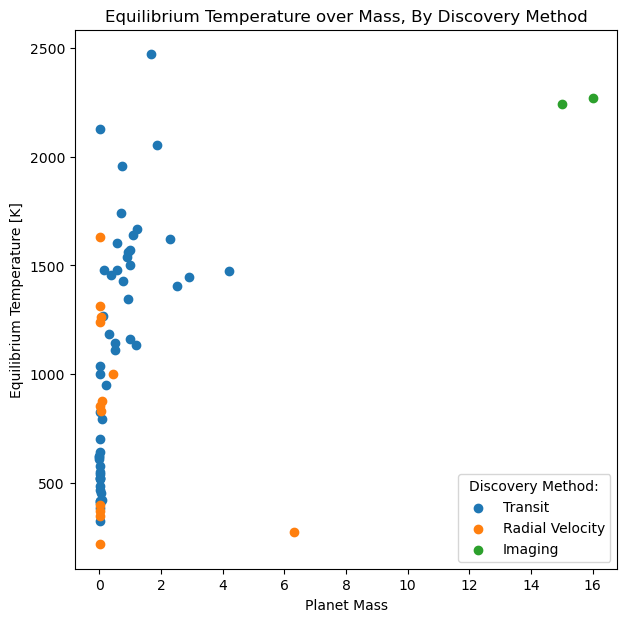

In [13]:
plt.figure(figsize = (7,7))

transitdata = df[df['discoverymethod'] == 'Transit']
radialvelocitydata = df[df['discoverymethod'] == 'Radial Velocity']
imagingdata = df[df['discoverymethod'] == 'Imaging']

plt.scatter(transitdata['pl_bmassj'],transitdata['pl_eqt'], label = 'Transit')
plt.scatter(radialvelocitydata['pl_bmassj'],radialvelocitydata['pl_eqt'], label = 'Radial Velocity')
plt.scatter(imagingdata['pl_bmassj'],imagingdata['pl_eqt'], label = 'Imaging')
plt.xlabel('Planet Mass')
plt.ylabel('Equilibrium Temperature [K]')
plt.title('Equilibrium Temperature over Mass, By Discovery Method')
plt.legend(title = 'Discovery Method:')
plt.show()


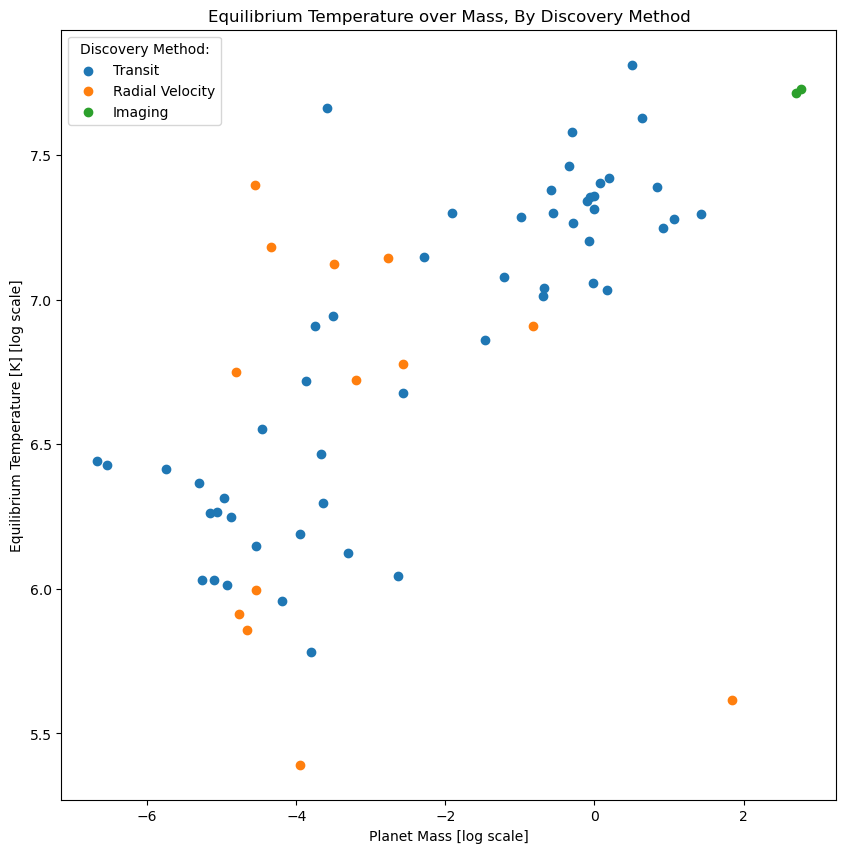

In [14]:
plt.figure(figsize = (10,10))

transitdata = df[df['discoverymethod'] == 'Transit']
radialvelocitydata = df[df['discoverymethod'] == 'Radial Velocity']
imagingdata = df[df['discoverymethod'] == 'Imaging']

plt.scatter(np.log(transitdata['pl_bmassj']),np.log(transitdata['pl_eqt']), label = 'Transit')
plt.scatter(np.log(radialvelocitydata['pl_bmassj']),np.log(radialvelocitydata['pl_eqt']), label = 'Radial Velocity')
plt.scatter(np.log(imagingdata['pl_bmassj']),np.log(imagingdata['pl_eqt']), label = 'Imaging')
plt.xlabel('Planet Mass [log scale]')
plt.ylabel('Equilibrium Temperature [K] [log scale]')
plt.title('Equilibrium Temperature over Mass, By Discovery Method')
plt.legend(title = 'Discovery Method:')
plt.show()

In [15]:
# Based on the data above, the exoplanets found by imaging are most likely to be massive

In [16]:
df_larger_than_5_JM = df[df['pl_bmassj'] >= 5]
print(df_larger_than_5_JM)
print()

df_coldest_w_gt_5_JM = df_larger_than_5_JM['pl_eqt'].min()
print(df_coldest_w_gt_5_JM)
print()

print(f'The coldest planet with mass larger than five Jupiter Masses is {df_larger_than_5_JM[df_larger_than_5_JM['pl_eqt'] == 275.0]['pl_name']}')
print()

print(df_larger_than_5_JM[df_larger_than_5_JM['pl_eqt'] == 275.0])
print()

print('The planets name is eps Ind A b and its index is 566. eps Ind Ab has a equilibrium temperature of 275.0 and it has a mass of 6.31 Jupiter masses. This planet is orbiting a K5 V star, which is different from our G2V type sun.')

         pl_name    hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
481   USco1556 b  USco1556 A          Imaging      M3.0 V  2240.0      15.00
482   USco1621 b  USco1621 A          Imaging      M2.5 V  2270.0      16.00
566  eps Ind A b   eps Ind A  Radial Velocity        K5 V   275.0       6.31

275.0

The coldest planet with mass larger than five Jupiter Masses is 566    eps Ind A b
Name: pl_name, dtype: object

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0       6.31

The planets name is eps Ind A b and its index is 566. eps Ind Ab has a equilibrium temperature of 275.0 and it has a mass of 6.31 Jupiter masses. This planet is orbiting a K5 V star, which is different from our G2V type sun.


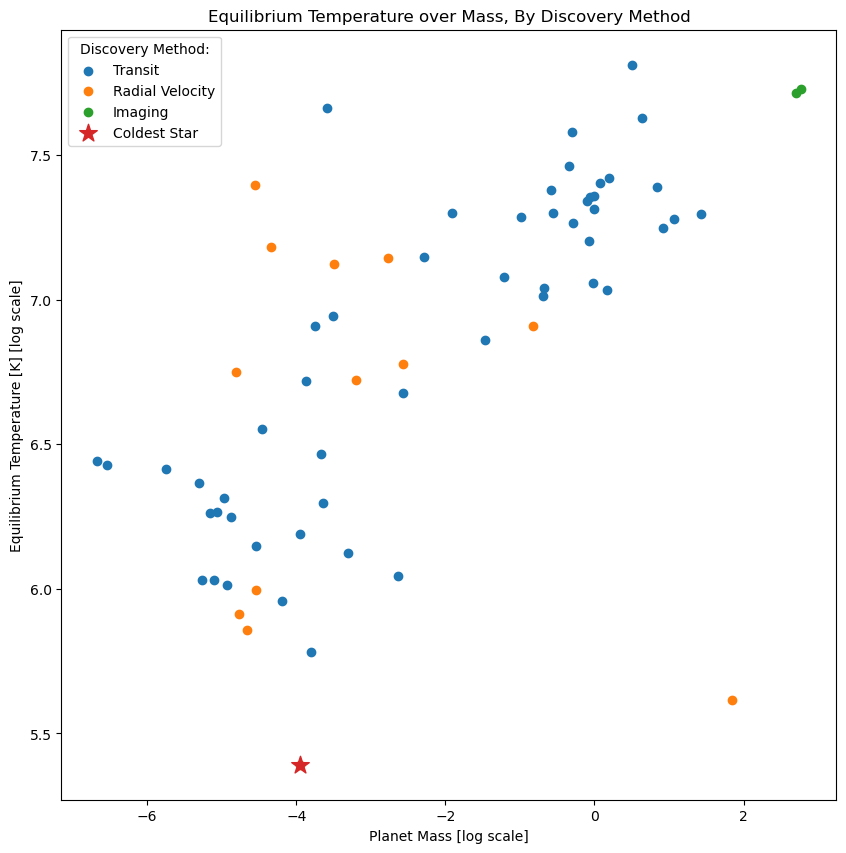

In [20]:
plt.figure(figsize = (10,10))

transitdata = df[df['discoverymethod'] == 'Transit']
radialvelocitydata = df[df['discoverymethod'] == 'Radial Velocity']
imagingdata = df[df['discoverymethod'] == 'Imaging']

plt.scatter(np.log(transitdata['pl_bmassj']),np.log(transitdata['pl_eqt']), label = 'Transit')
plt.scatter(np.log(radialvelocitydata['pl_bmassj']),np.log(radialvelocitydata['pl_eqt']), label = 'Radial Velocity')
plt.scatter(np.log(imagingdata['pl_bmassj']),np.log(imagingdata['pl_eqt']), label = 'Imaging')
plt.scatter(np.log(df[df['pl_eqt'] == df['pl_eqt'].min()]['pl_bmassj']), np.log(df[df['pl_eqt'] == df['pl_eqt'].min()]['pl_eqt']), label = 'Coldest Star', s = 175, marker = '*')
plt.xlabel('Planet Mass [log scale]')
plt.ylabel('Equilibrium Temperature [K] [log scale]')
plt.title('Equilibrium Temperature over Mass, By Discovery Method')
plt.legend(title = 'Discovery Method:')
plt.show()

In [21]:
# What is the title of this paper?
# A temperate super-Jupiter imaged with JWST in the mid-infrared

# Summarize the abstract to the best of your ability in your own words.
# A giant exoplanet has been detected orbiting a nearby star, Eps Ind A. This planet has
# an approximate temperature of 275 K. Based on the opacity of its atmosphere, the planet
# likely has a high carbon-to-oxygen ratio. We label this planet as b because it seems to be
# the only giant in its system.

# Does your answer match the exoplanet?
# Yes, my answer matches the exoplanet detailed in the article. They both orbit the same star
# (Eps Ind A), have the same 'b' label. The planets identified in my work and in the article both have
# a temperature of 275 K.

# What is special about the planet you found?
# This planet is special because it is likely the biggest planet in its system!

# Do the mass and equilibrium temperature match what the paper reported? 
# If not, what are the differences?
# Yes, they have the same equilibrium temperature (of 275 K) and mass (6.31 Jupiter masses).